Configuración y Limpieza

In [6]:
import pandas as pd
import numpy as np

# 1. Carga de datos
df_listings = pd.read_csv('../data/listings_limpio.csv')
df_rentas = pd.read_csv('../data/renta_sevilla_capital_limpio.csv')
df_calendar = pd.read_csv('../data/calendar_limpio.csv.zip', compression='zip', parse_dates=['date'])

# Calculamos la renta media por Distrito.
renta_por_distrito = df_rentas.groupby('distrito_limpio')['Total'].mean().reset_index()

# Merge 1: Unimos los precios de Airbnb con la info del piso.
df = pd.merge(df_calendar, df_listings[['id', 'neighbourhood_group_cleansed', 'price']],left_on='listing_id', right_on='id', how='left')

# Merge 2: Unimos el resultado anterior con la renta media por distrito.
airbnb = pd.merge(df, renta_por_distrito, left_on='neighbourhood_group_cleansed', right_on='distrito_limpio', how='left')

# 2. Mapeamos eventos importantes en Sevilla para etiquetar los días.
def etiquetar_evento(fecha):
    fecha_str = str(fecha.date())
    
    # SEMANA SANTA
    if ('2025-04-13' <= fecha_str <= '2025-04-20') or ('2026-03-29' <= fecha_str <= '2026-04-05'):
        return 'Semana Santa'
    
    # FERIA DE ABRIL
    elif ('2025-05-06' <= fecha_str <= '2025-05-11') or ('2026-04-21' <= fecha_str <= '2026-04-26'):
        return 'Feria de Abril'
    
    else:
        return 'Normal'



# Crear nuevas columnas basadas en la fecha y el evento.
airbnb['evento'] = airbnb['date'].apply(etiquetar_evento)
airbnb['mes'] = airbnb['date'].dt.month_name()
airbnb['dia_semana'] = airbnb['date'].dt.day_name()
airbnb['es_finde'] = airbnb['date'].dt.dayofweek.isin([4, 5, 6]) # Viernes, Sábado, Domingo

# Temporada Alta/Baja (Criterio de negocio)
# Definimos Alta como los meses de primavera/verano en Sevilla (abril a junio y septiembre a octubre)
airbnb['temporada'] = airbnb['date'].dt.month.apply(
    lambda x: 'Alta' if x in [3, 4, 5, 9, 10] else 'Baja')


# 3. Efecto Fiestas en Sevilla.
# Convertimos 'available' a numérico para poder operar: 't' (true) significa libre, 'f' (false) significa ocupado.
# Creamos una columna 'ocupado' donde 1 significa que alguien lo ha alquilado.
airbnb['ocupado'] = airbnb['available'].map({True: 0, False: 1})

# Calculamos la ocupación media por evento
ocupacion_eventos = airbnb.groupby('evento')['ocupado'].mean() * 100

# Calculamos la "Inflación de Demanda": Porcentaje de ocupación en Feria vs un día Normal
ocup_normal = ocupacion_eventos['Normal']
ocup_feria = ocupacion_eventos['Feria de Abril']
subida_demanda = ocup_feria - ocup_normal

print(f"Ocupación media en Feria: {ocup_feria:.2f}%")
print(f"Ocupación media normal: {ocup_normal:.2f}%")
print(f"Durante la Feria, la ocupación sube un {subida_demanda:.2f}% respecto al resto del año.")

Ocupación media en Feria: 59.11%
Ocupación media normal: 49.22%
Durante la Feria, la ocupación sube un 9.88% respecto al resto del año.


Inflación de los precios por las fiestas

/var/folders/93/vz3z14x529n5vnjy2ttykz8h0000gn/T/ipykernel_39370/412241846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ocupacion_eventos.index, y=ocupacion_eventos.values, palette='viridis')


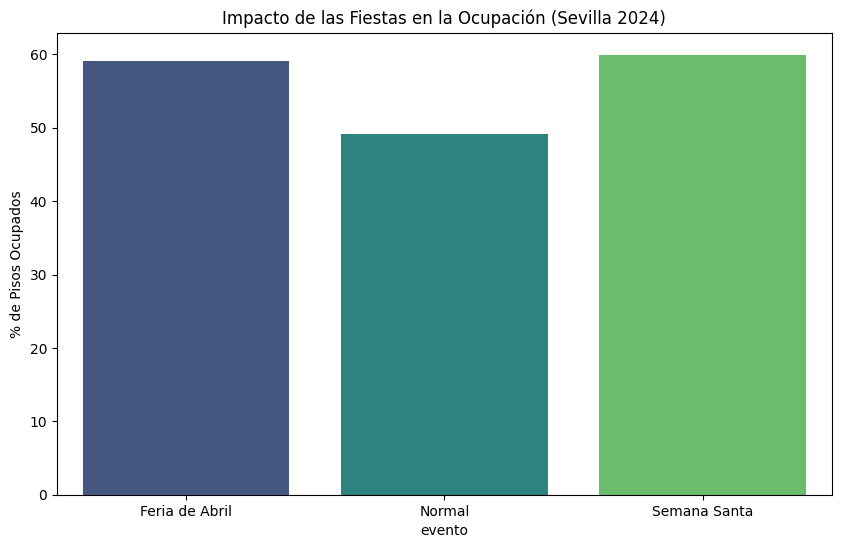

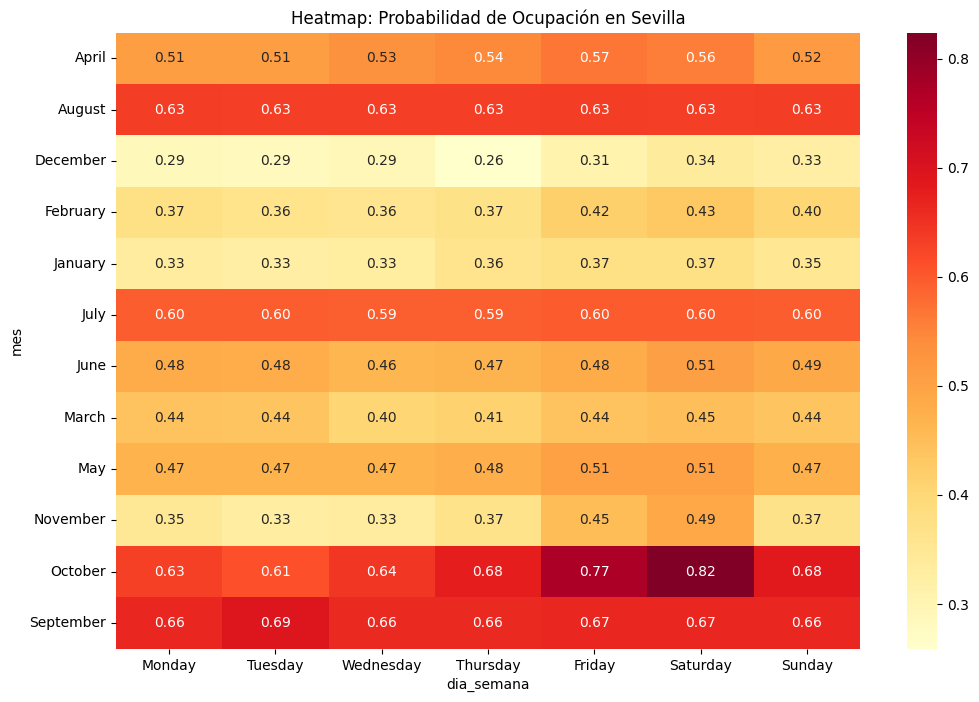

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico Comparativo
plt.figure(figsize=(10, 6))
sns.barplot(x=ocupacion_eventos.index, y=ocupacion_eventos.values, palette='viridis')
plt.title('Impacto de las Fiestas en la Ocupación (Sevilla 2024)')
plt.ylabel('% de Pisos Ocupados')
plt.show()

# Mapa de calor de la demanda.
# Creamos una tabla pivote: Mes vs Día de la semana
pivot_ocupacion = airbnb.pivot_table(
    index='mes', 
    columns='dia_semana', 
    values='ocupado', 
    aggfunc='mean'
)

# Ordenamos los días para que el gráfico tenga sentido
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_ocupacion = pivot_ocupacion.reindex(columns=dias_ordenados)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ocupacion, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Heatmap: Probabilidad de Ocupación en Sevilla')
plt.show()

Business Intelligence


In [7]:
# 1. Análisis de Grandes Tenedores (Profesionalización)
# Creamos una marca: Profesional (>5 pisos) vs Particular (<=5)
df_listings['tipo_host'] = df_listings['calculated_host_listings_count'].apply(
    lambda x: 'Profesional' if x > 5 else 'Particular'
)

# Unimos esta info al dataframe principal si no estaba
if 'tipo_host' not in airbnb.columns:
    airbnb = pd.merge(airbnb, df_listings[['id', 'tipo_host']], left_on='listing_id', right_on='id', how='left')

# 2. Agrupamos por anuncio para tener el detalle individual
stats_anuncio = airbnb.groupby('listing_id').agg({
    'price': 'mean',
    'ocupado': 'sum', # Noches totales reservadas
    'neighbourhood_group_cleansed': 'first',
    'tipo_host': 'first'
})

# 3. Calculamos la ganancia de cada anuncio
stats_anuncio['ganancia_total'] = stats_anuncio['price'] * stats_anuncio['ocupado']

# --- RESPUESTAS A TU PREGUNTA ---

# A. Ganancia media por ANUNCIO en toda Sevilla:
media_sevilla = stats_anuncio['ganancia_total'].mean()
print(f"💰 Ganancia media por piso en Sevilla: {media_sevilla:.2f}€")

# B. Ganancia media por BARRIO (Punto 5: Ranking):
ganancia_barrio = stats_anuncio.groupby('neighbourhood_group_cleansed')['ganancia_total'].mean().sort_values(ascending=False)
print("\n📍 Ganancia media por Distrito:")
print(ganancia_barrio)

# C. Ganancia media por TIPO DE DUEÑO (Punto 5: Grandes Tenedores):
ganancia_tipo_host = stats_anuncio.groupby('tipo_host')['ganancia_total'].mean()
print("\n🏨 Ganancia media: Profesionales vs Particulares:")
print(ganancia_tipo_host)

💰 Ganancia media por piso en Sevilla: 27897.73€

📍 Ganancia media por Distrito:
neighbourhood_group_cleansed
Sur                            34088.104000
Triana                         29616.848060
Casco Antiguo                  29207.454127
Nervión                        27635.121145
San Pablo - Santa Justa        26788.630952
Los Remedios                   18389.972028
Palmera - Bellavista           15099.559633
Macarena                       14854.088106
Este - Alcosa - Torreblanca    14539.820513
Macarena - Norte               13316.122449
Cerro - Amate                  12171.766667
Name: ganancia_total, dtype: float64

🏨 Ganancia media: Profesionales vs Particulares:
tipo_host
Particular     26703.159600
Profesional    29096.398784
Name: ganancia_total, dtype: float64


Visualización

/var/folders/93/vz3z14x529n5vnjy2ttykz8h0000gn/T/ipykernel_16911/2024867706.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


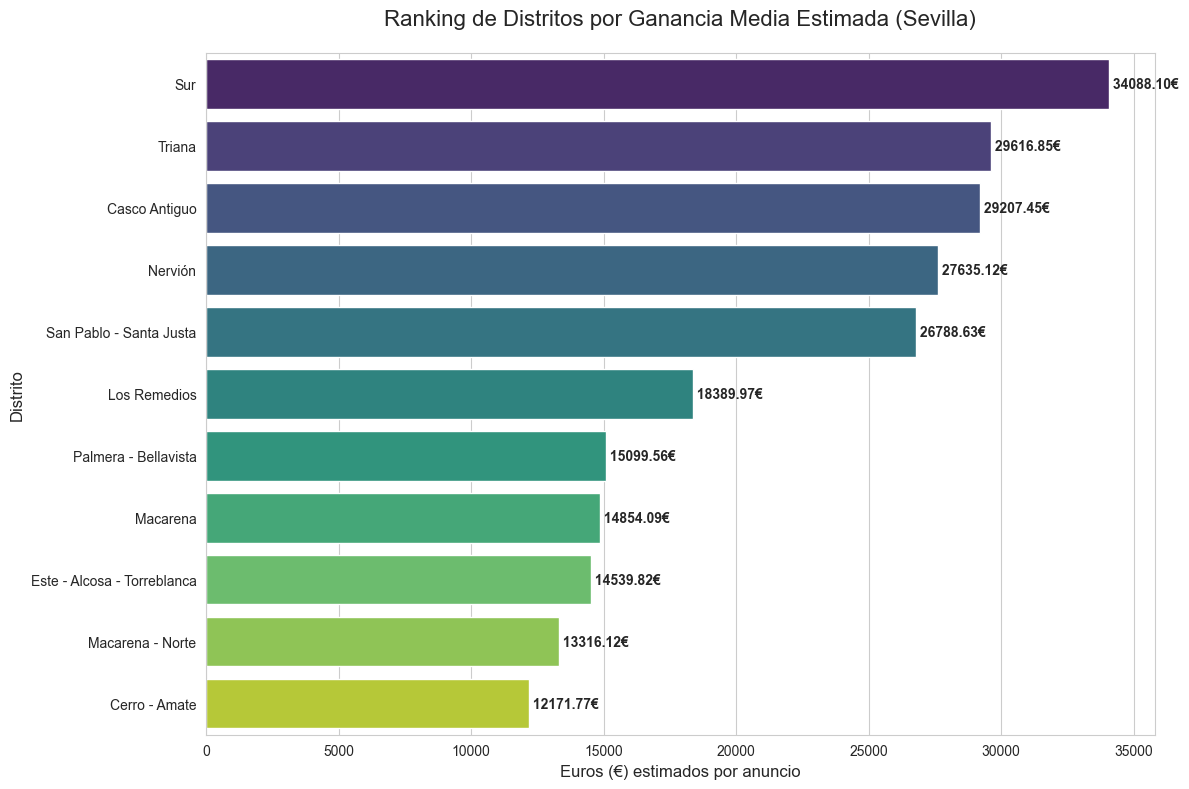

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns # Asegúrate de tener importado seaborn como sns

# 1. Calculamos la ganancia por cada anuncio (usando la columna 'ocupado' que ya creamos)
# Agrupamos por ID de anuncio para sumar sus noches ocupadas
df_ganancias = airbnb.groupby('listing_id').agg({
    'price': 'mean',
    'ocupado': 'sum',
    'neighbourhood_group_cleansed': 'first'
}).reset_index()

# Ganancia total = Precio medio * Noches totales que se ha llenado
df_ganancias['ganancia_total'] = df_ganancias['price'] * df_ganancias['ocupado']

# 2. Agrupamos por DISTRITO para ver la media de ingresos
ranking_distritos = df_ganancias.groupby('neighbourhood_group_cleansed')['ganancia_total'].mean().sort_values(ascending=False).reset_index()

# 3. CREACIÓN DEL GRÁFICO DE BARRAS
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Usamos una paleta de colores degradada para que quede más profesional
grafico = sns.barplot(
    data=ranking_distritos, 
    x='ganancia_total', 
    y='neighbourhood_group_cleansed', 
    palette='viridis'
)

# Añadimos etiquetas de datos al final de cada barra para que se lea el número exacto
for i, valor in enumerate(ranking_distritos['ganancia_total']):
    plt.text(valor, i, f' {valor:.2f}€', va='center', fontsize=10, fontweight='bold')

plt.title('Ranking de Distritos por Ganancia Media Estimada (Sevilla)', fontsize=16, pad=20)
plt.xlabel('Euros (€) estimados por anuncio', fontsize=12)
plt.ylabel('Distrito', fontsize=12)

# Ajustamos para que no se corten los nombres
plt.tight_layout()
plt.show()